In [10]:
# 1. Locate the project root and activate the environment
const PROJECT_ROOT = let
    dir = @__DIR__
    while !isfile(joinpath(dir, "Project.toml")) && dir != dirname(dir)
        dir = dirname(dir)
    end
    dir
end

using Pkg
Pkg.activate("..") # or PROJECT_ROOT

# 2. Include the simulation sources (automatically imports required packages from utils.jl)
include(joinpath(PROJECT_ROOT, "src", "simulation.jl"))
include(joinpath(PROJECT_ROOT, "src", "simulation_liquid.jl"))

using Random, NPZ, Plots

  Activating project at `/data/UNIVERSITA/PhD/PROJECTS/CancerEvo`
  Activating project at `/data/UNIVERSITA/PhD/PROJECTS/CancerEvo`
  Activating project at `/data/UNIVERSITA/PhD/PROJECTS/CancerEvo`
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (14), dep missing source (2))
┌ Warning: Module StatsBase with build ID fafbfcfd-bde3-a9bb-0000-0088155c8bd5 is missing from the cache.
│ This may mean StatsBase [2913bbd2-ae8a-5f71-8c99-4fb6c76f3a91] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Info: Skipping precompilation due to precompilable error. Importing Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b] (cache misses: wrong dep version loaded (12))
[ Info: Precompiling JLFzf [1019f520

In [255]:
# ==========================================
# PART 1: Run Solid Tumor Simulation
# ==========================================

# Load parameters for the Solid Case
include(joinpath(PROJECT_ROOT, "scripts", "solid", "parameters.jl"))

println("--- Starting Solid Tumor Simulation ---")
println("L = $L, steps = $n_steps, N_CHR = $N_CHR")

Random.seed!(time_ns())

# Initialize tissue
tiss_solid = OptimizedTissue(L, N_I, N_O, N_S, N_M, N_HK, mu0, 0.019, r0, 0.015, rmax, dm, N_CHR)

println("Applying initial perturbation...")
perturb_optimized!(tiss_solid, 0.1, pert_chrs)

println("Running simulation loop with missegregation mechanism: ", misseg_type)
results_solid = simulation_optimized(tiss_solid, N_CHR, n_steps, n_it_store, false, limit, 0.0, misseg_type)

# Save results
output_dir_solid = joinpath(PROJECT_ROOT, "data", "simulations")
if !isdir(output_dir_solid); mkpath(output_dir_solid); end

output_file_solid = joinpath(output_dir_solid, "results.npz")
println("Saving solid results to $output_file_solid ...")

results_dict_solid = Dict(
    "mu" => results_solid.mu,
    "r" => results_solid.r,
    "m" => results_solid.m,
    "n_chrs" => results_solid.n_chrs,
    "tumor_density" => results_solid.tumor_density,
    "death_density" => results_solid.dcells_density,
    "outcome_code" => [results_solid.state == "Health" ? 0 : results_solid.state == "Tumor" ? 1 : 2]
)
for (i, type) in enumerate(["I", "O", "S", "M", "HK"])
    results_dict_solid["mut_$(type)"] = results_solid.muts[i]
    results_dict_solid["act_$(type)"] = results_solid.activations[i]
end
println("Solid simulation finished. Outcome: ", results_solid.state)

--- Starting Solid Tumor Simulation ---
L = 200, steps = 2500, N_CHR = 2
Applying initial perturbation...
Running simulation loop with missegregation mechanism: whole
Completed steps
Saving solid results to /data/UNIVERSITA/PhD/PROJECTS/CancerEvo/data/simulations/results.npz ...
Solid simulation finished. Outcome: Done


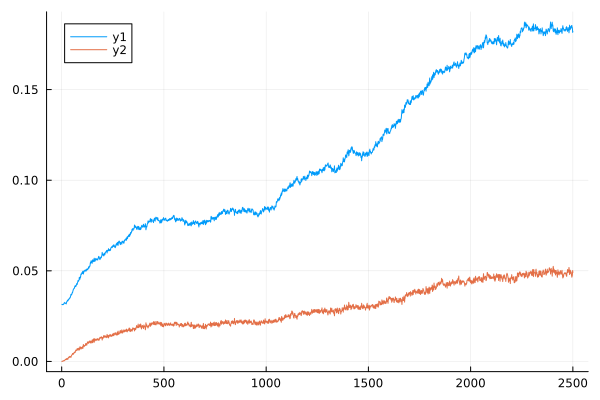

In [261]:
plot((results_dict_solid["tumor_density"]))
plot!(results_dict_solid["death_density"])

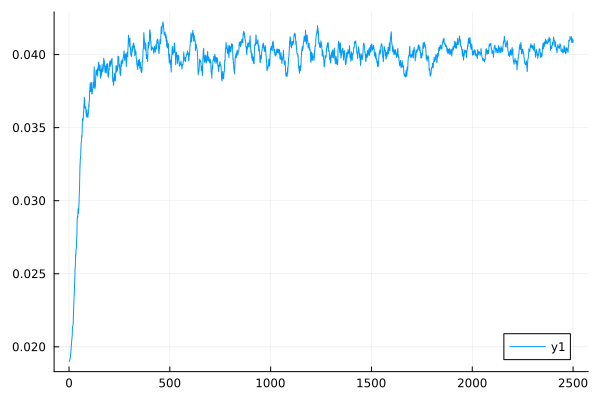

In [257]:
plot(results_dict_solid["mu"])

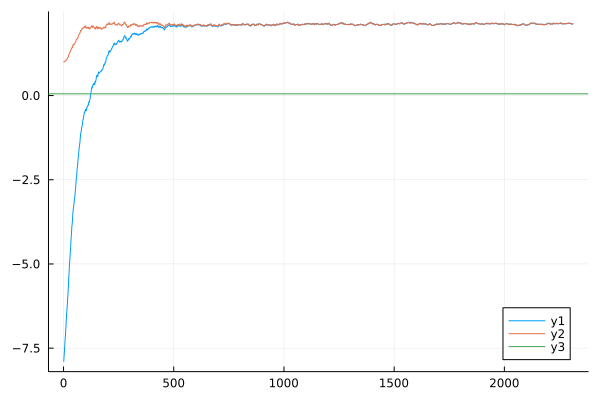

In [246]:
plot((results_dict_solid["mut_I"].-0.5).*20)
plot!(results_dict_solid["act_I"])
hline!([0.0512])

In [263]:
cancer_idx = findall(tiss_solid.state .== 1)
fractions = if isempty(cancer_idx)
    zeros(Float64, count_ones(tiss_solid.mask_I) + 1)
else
    i_levels = [count_ones(reduce(&, tiss_solid.chromosomes[1:tiss_solid.n_chrs[idx], idx]) & tiss_solid.mask_I) for idx in cancer_idx]
    [count(==(k), i_levels) / length(i_levels) for k in 0:count_ones(tiss_solid.mask_I)]
end

11-element Vector{Float64}:
 0.0
 0.4077123644846988
 0.28283244133388225
 0.1576780568135035
 0.08576917798819816
 0.039796898586523945
 0.017428296967201867
 0.005626458076025799
 0.002607383010841224
 0.0005489227391244682
 0.0

In [264]:
tiss_solid

# 1. Get the mutated I gene level (0 to N_I) for each cancer cell
i_levels = [count_ones(reduce(&, tiss_solid.chromosomes[1:tiss_solid.n_chrs[idx], idx]) & tiss_solid.mask_I) for idx in findall(tiss_solid.state .== 1)]
# 2. Compute the fraction for each level k from 0 to N_I
fractions = [count(==(k), i_levels) / length(i_levels) for k in 0:count_ones(tiss_solid.mask_I)]

11-element Vector{Float64}:
 0.0
 0.4077123644846988
 0.28283244133388225
 0.1576780568135035
 0.08576917798819816
 0.039796898586523945
 0.017428296967201867
 0.005626458076025799
 0.002607383010841224
 0.0005489227391244682
 0.0

In [167]:

# ==========================================
# PART 2: Run Liquid Tumor Simulation
# ==========================================

# Load parameters for the Liquid Case (overwrites shared parameters)
include(joinpath(PROJECT_ROOT, "scripts", "liquid", "parameters_liquid.jl"))

println("\n--- Starting Liquid Tumor Simulation ---")
println("L = $L, steps = $n_steps, N_CHR = $N_CHR")

Random.seed!(time_ns())

# Initialize tissue (Moran process operates on L*L well-mixed cells)
tiss_liquid = LiquidTissue(L * L, N_I, N_O, N_S, N_M, N_HK, mu0, 0.018, r0, 0.006, 2*r0, dm, N_CHR)

println("Seeding $n_seed cancer cells at random positions (liquid perturbation)...")
perturb_liquid!(tiss_liquid, n_seed, pert_chrs)

println("Running simulation loop with missegregation mechanism: ", misseg_type)
results_liquid = simulation_liquid(tiss_liquid, N_CHR, n_steps, n_it_store, false, 0.95, 0.0, misseg_type)

# Save results
output_dir_liquid = joinpath(PROJECT_ROOT, "data", "simulations_liquid")
if !isdir(output_dir_liquid); mkpath(output_dir_liquid); end

output_file_liquid = joinpath(output_dir_liquid, "results.npz")
println("Saving liquid results to $output_file_liquid ...")

results_dict_liquid = Dict(
    "mu"            => results_liquid.mu,
    "r"             => results_liquid.r,
    "m"             => results_liquid.m,
    "n_chrs"        => results_liquid.n_chrs,
    "tumor_density" => results_liquid.tumor_density,
    "death_density" => results_liquid.dcells_density,
    "outcome_code"  => [results_liquid.state == "Health"    ? 0 :
                        results_liquid.state == "Tumor_Max" ? 1 :
                        results_liquid.state == "Tumor_Min" ? 3 : 2]
)
for (i, type) in enumerate(["I", "O", "S", "M", "HK"])
    results_dict_liquid["mut_$(type)"] = results_liquid.muts[i]
    results_dict_liquid["act_$(type)"] = results_liquid.activations[i]
end
println("Liquid simulation finished. Outcome: ", results_liquid.state)



--- Starting Liquid Tumor Simulation ---


L = 200, steps = 2500, N_CHR = 2
Seeding 10 cancer cells at random positions (liquid perturbation)...
Running simulation loop with missegregation mechanism: whole
Completed steps
Saving liquid results to /data/UNIVERSITA/PhD/PROJECTS/CancerEvo/data/simulations_liquid/results.npz ...
Liquid simulation finished. Outcome: Done


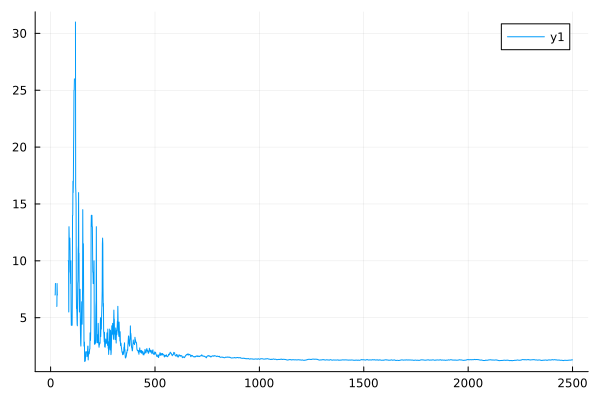

In [183]:
plot(results_dict_liquid["tumor_density"]./results_dict_liquid["death_density"])
#plot!(results_dict_liquid["death_density"])


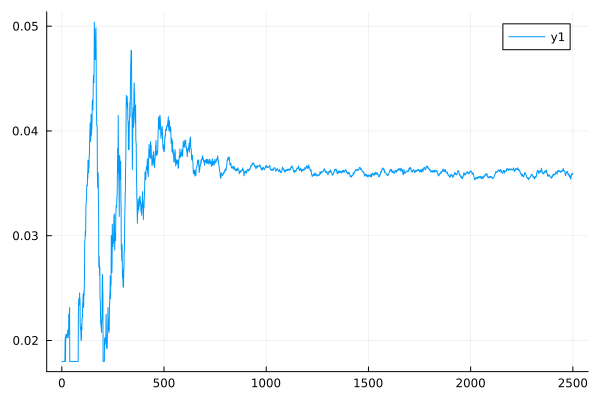

In [169]:
plot(results_dict_liquid["mu"])


In [172]:
0.15+0.006*20

0.27

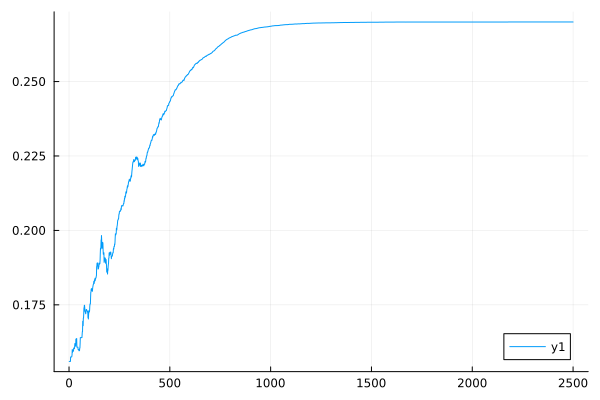

In [170]:
plot(results_dict_liquid["r"])


In [152]:
mean(results_dict_liquid["mu"][1000:2000])

0.04237635304468944